In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.listdir('/content')
import zipfile
import os

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/retail_data')

os.listdir('/content/retail_data')
import pandas as pd

df = pd.read_csv('/content/retail_data/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Transaction ID,1000
Date,345
Customer ID,1000
Gender,2
Age,47
Product Category,3
Quantity,4
Price per Unit,5
Total Amount,18


In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 9)


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Date'].head()

,Date
0,2023-11-24
1,2023-02-27
2,2023-01-13
3,2023-05-21
4,2023-05-06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


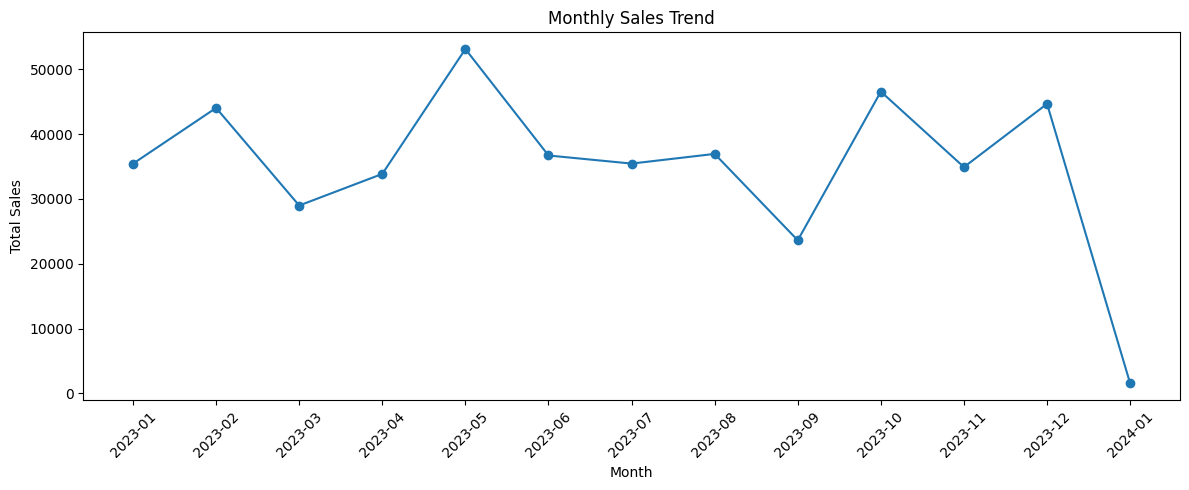

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

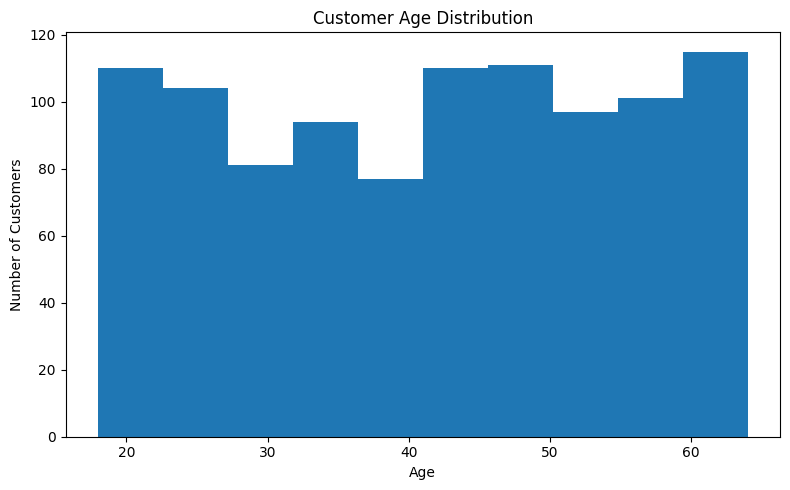

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=10)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


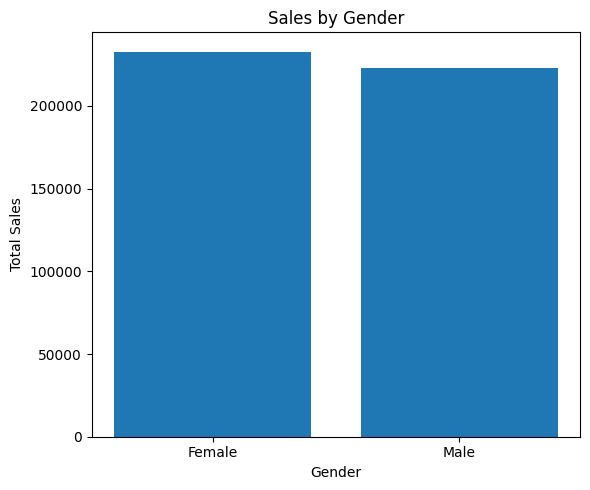

In [ ]:
plt.figure(figsize=(6, 5))
plt.bar(gender_sales.index, gender_sales.values)
plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month'],
      dtype='object')

In [ ]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

top_products

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


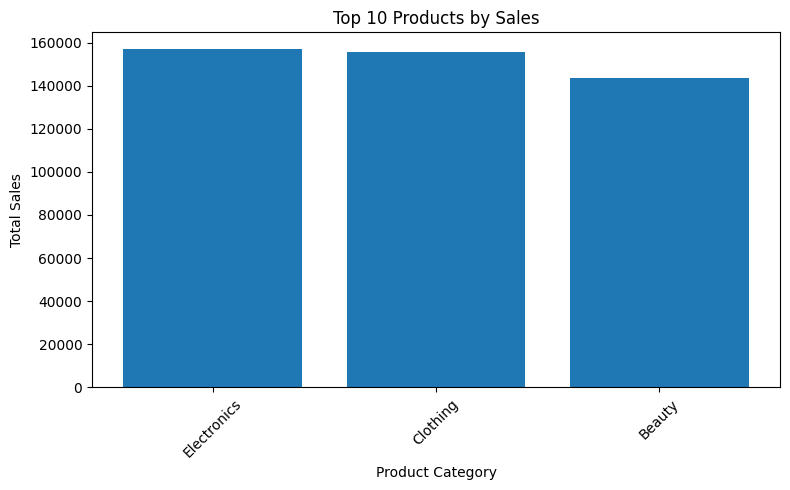

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


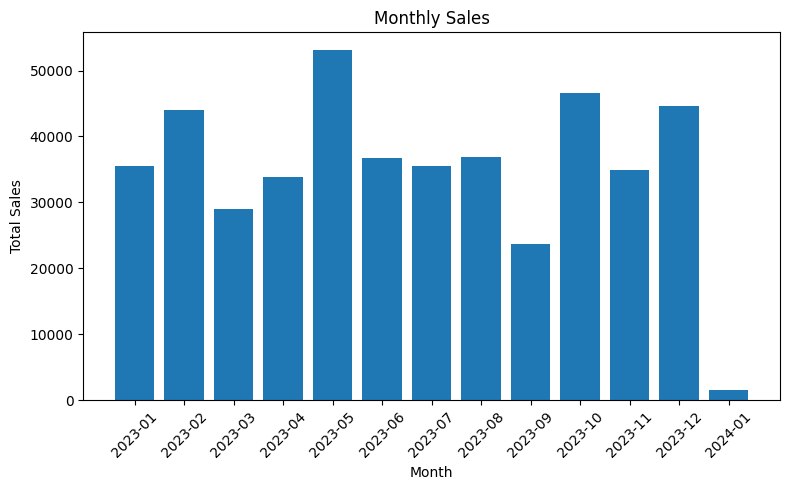

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
age_sales = df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False)

age_sales.head(10)

,Total Amount
Age,
43,17970
34,16785
51,16065
19,14870
26,13980
22,13700
46,13090
21,12585
47,12505


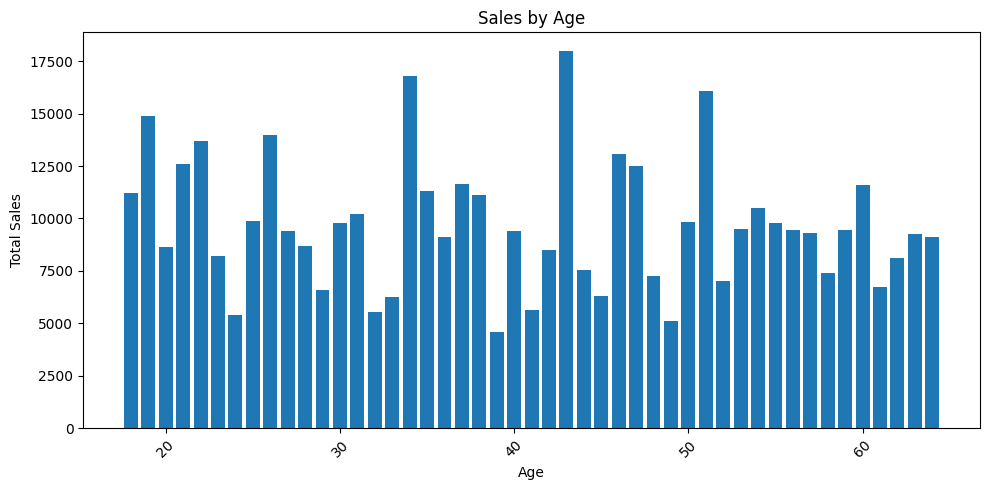

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(age_sales.index, age_sales.values)

plt.title('Sales by Age')
plt.xlabel('Age')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

category_quantity

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


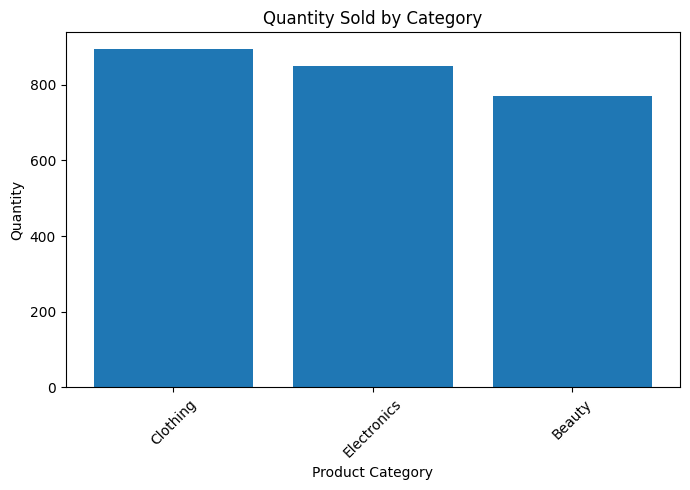

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(category_quantity.index, category_quantity.values)
plt.title('Quantity Sold by Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

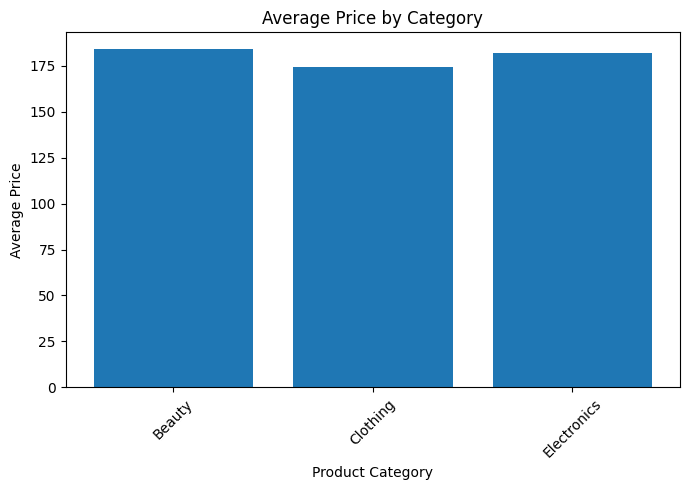

In [ ]:
avg_price = df.groupby('Product Category')['Price per Unit'].mean()

plt.figure(figsize=(7,5))
plt.bar(avg_price.index, avg_price.values)
plt.title('Average Price by Category')
plt.xlabel('Product Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
total_sales = df['Total Amount'].sum()
total_quantity = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)

Total Sales: 456000
Total Quantity Sold: 2514


In [ ]:
df['Total Amount'].describe()

,Total Amount
count,1000.000000
mean,456.000000
std,559.997632
min,25.000000
25%,60.000000
50%,135.000000
75%,900.000000
max,2000.000000


In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05


In [ ]:
df.to_csv('final_sales_data.csv', index=False)
print("File saved successfully!")

File saved successfully!
